# 02 - Data Cleaning: Making the Data Trustworthy

**Goal:** Prepare the raw weather data for modeling. "Clean" means the data
is:

- **complete** (no missing values),
- **consistent** (correct types, valid date order),
- **correct** (no physically impossible values),
- and that **every cleaning decision is explained**.

The golden rule of this phase: **do not blindly delete data**. We only remove
or change something when we can justify it. In weather data, a "weird-looking"
extreme value is often a *real* event (a flood!) - deleting it would hide
exactly the rare events we want to predict.


## Setup and loading

We load the raw dataset saved in Phase 1 and run our cleaning checks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

FIG_DIR = Path("reports/figures")
if not FIG_DIR.exists():
    FIG_DIR = Path("..") / "reports/figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RAW = Path("data/raw/karachi_weather.csv")
if not RAW.exists():
    RAW = Path("..") / "data/raw/karachi_weather.csv"

df = pd.read_csv(RAW, parse_dates=["Date"])
print("Loaded:", df.shape)
print("Rows:", len(df), "| Columns:", len(df.columns))

Loaded: (15198, 12)
Rows: 15198 | Columns: 12


## 1. Missing values

Missing values would create "holes" the model cannot reason about. We already
know there are none, but we always re-check at the start of cleaning.


In [2]:
missing = df.isna().sum()
print("Total missing cells:", missing.sum())
print(df[missing > 0]) if missing.sum() else print("No missing values in any column.")

Total missing cells: 0
No missing values in any column.


## 2. Duplicate rows and duplicate dates

Exact duplicate rows would let one day count twice. Duplicate **dates** would
mean the same day has conflicting weather records. Both are checked.


In [3]:
print("Duplicate rows :", df.duplicated().sum())
print("Duplicate dates:", df["Date"].duplicated().sum())

Duplicate rows : 0
Duplicate dates: 0


## 3. Date quality

We need a clean, complete, chronological timeline. We check that dates are
sorted, span the expected range, and have no gaps.

A "gap" is a day with no observation. Because our target will be
**RainTomorrow** (based on the *next* day's rain), a gap would break the
chain: yesterday's rain would be missing.


In [4]:
print("Sorted ascending      :", df["Date"].is_monotonic_increasing)
print("Earliest              :", df["Date"].min().date())
print("Latest                :", df["Date"].max().date())

full_range = pd.date_range(df["Date"].min(), df["Date"].max(), freq="D")
missing_days = set(full_range) - set(df["Date"])
print("Expected days        :", len(full_range))
print("Days present         :", len(df))
print("Missing days (gaps)  :", len(missing_days))
if missing_days:
    print("First few gaps:", sorted(missing_days)[:5])

Sorted ascending      : True
Earliest              : 1985-01-01
Latest                : 2026-08-11
Expected days        : 15198
Days present         : 15198
Missing days (gaps)  : 0


## 4. Data types

Every column must have a sensible type. `Date` must be datetime; weather
measurements should be numeric. Correct types prevent silent bugs later.


In [5]:
types = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum().astype(str),
})
print(types)

                          dtype missing
Date             datetime64[us]       0
MaxTemperature          float64       0
MinTemperature          float64       0
MeanTemperature         float64       0
Precipitation           float64       0
Rainfall                float64       0
Pressure                float64       0
Humidity                  int64       0
CloudCoverage             int64       0
WindSpeed               float64       0
WindDirection             int64       0
WeatherCode               int64       0


## 5. Plausibility checks

We define a physically sensible range for each variable and flag any value
outside it. These ranges are chosen from weather science:

| Variable        | Sensible range   | Why |
|-----------------|------------------|-----|
| Humidity        | 0 - 100 %        | Relative humidity is a percentage |
| CloudCoverage   | 0 - 100 %        | Percentage of sky covered |
| WindDirection   | 0 - 360 deg      | Compass degrees |
| WindSpeed       | >= 0 km/h        | Speed cannot be negative |
| Pressure        | 850 - 1100 hPa   | Extreme lows/highs of sea-level pressure |
| Temperature     | -20 to 60 C      | Outside this range is unphysical for Karachi |
| Rainfall        | >= 0 mm          | Can't have negative rain |
| WeatherCode     | 0 - 99           | WMO weather condition codes |


In [6]:
checks = {
    "Humidity": (0, 100),
    "CloudCoverage": (0, 100),
    "WindDirection": (0, 360),
    "WindSpeed": (0, None),
    "Pressure": (850, 1100),
    "MaxTemperature": (-20, 60),
    "MinTemperature": (-20, 60),
    "Rainfall": (0, None),
    "WeatherCode": (0, 99),
}

report = []
for col, (lo, hi) in checks.items():
    bad = df[col]
    bad = bad[(bad < lo) if lo is not None else False]
    if hi is not None:
        bad = bad[(bad > hi)] if lo is not None else df[col][(df[col] > hi)]
    report.append({
        "column": col,
        "min": df[col].min(),
        "max": df[col].max(),
        "violations": int(len(bad)),
    })

check_df = pd.DataFrame(report)
print(check_df)
print("\nTotal out-of-range values:", int(check_df["violations"].sum()))

           column    min     max  violations
0        Humidity   14.0    92.0           0
1   CloudCoverage    0.0   100.0           0
2   WindDirection    0.0   360.0           0
3       WindSpeed    7.7    50.5           0
4        Pressure  990.9  1023.7           0
5  MaxTemperature   16.1    44.8           0
6  MinTemperature    7.7    32.6           0
7        Rainfall    0.0   304.9           0
8     WeatherCode    0.0    65.0           0

Total out-of-range values: 0


### Interpretation

**Zero violations.** Every value in the dataset is physically plausible. This
means the cleaning needs are minimal - which is good news: it also means we do
*not* need to drop any rows.

Note: `WindDirection == 360` is valid (compass degrees are 0-360), and
`CloudCoverage == 100` means a fully overcast day, which is valid too.


## 6. Outliers - the weather perspective

A classic mistake is to delete outliers via statistics (e.g., anything beyond
1.5 x IQR). For weather data this is **dangerous**, because extreme values are
often exactly the events we care about. Let's look at the extreme rainfall days.


In [7]:
print("Rainfall quantiles:")
print(df["Rainfall"].quantile([0.50, 0.90, 0.99, 0.999]).round(1))
print()
print("Days with > 100 mm rain:", int((df["Rainfall"] > 100).sum()))
print()
print(df[df["Rainfall"] > 100][["Date", "Rainfall", "Humidity", "Pressure"]].to_string(index=False))

Rainfall quantiles:
0.500     0.0
0.900     0.2
0.990    11.0
0.999    48.5
Name: Rainfall, dtype: float64

Days with > 100 mm rain: 5

      Date  Rainfall  Humidity  Pressure
1985-07-18     129.8        87     997.5
1988-07-23     122.4        91     996.7
1989-07-26     116.5        88     992.7
2019-08-11     304.9        91     993.9
2022-07-24     162.3        88     998.9


### What these extremes really are

The 5 days with > 100 mm are the **record monsoon floods** in Karachi's
history (e.g., the catastrophic July-August 2022 floods). These are not data
errors - they are real, catastrophic weather events.

**Decision: we KEEP all of them.**

Why?
1. They are not errors - they genuinely happened.
2. A rain-prediction model must learn to predict rare heavy-rain events.
3. Removing them would make the model systematically underestimate rain.

The only reason to remove a value is proof that it is **wrong**, not merely
that it is *extreme*.


## 7. Quick visual confirmation

A boxplot of rainfall by month shows the "extreme" points cluster exactly in
the monsoon months - consistent with known Karachi weather, another sign they
are real.


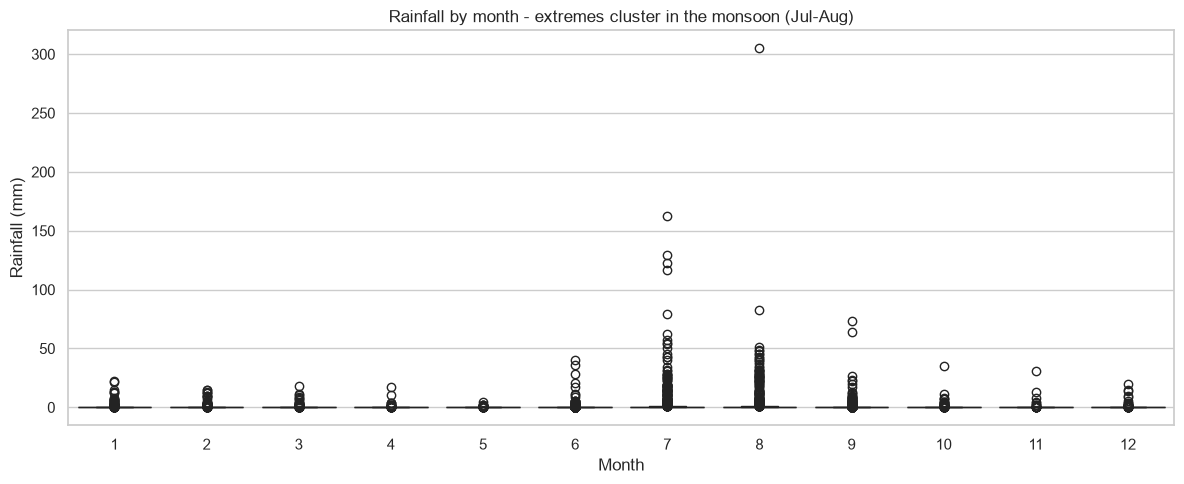

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
df["Month"] = df["Date"].dt.month
sns.boxplot(x="Month", y="Rainfall", data=df, ax=ax, hue="Month", legend=False, palette="Blues")
ax.set_title("Rainfall by month - extremes cluster in the monsoon (Jul-Aug)")
ax.set_xlabel("Month")
ax.set_ylabel("Rainfall (mm)")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_rainfall_outliers_by_month.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Cleaning decisions summary

| Check                | Result          | Decision                      | Why |
|----------------------|-----------------|-------------------------------|-----|
| Missing values       | 0               | Nothing to do                 | Data is complete |
| Duplicate rows       | 0               | Nothing to do                 | No double-counted days |
| Duplicate dates      | 0               | Nothing to do                 | One observation per day |
| Date order           | sorted, no gaps | Nothing to do                 | Timeline is complete |
| Data types           | correct         | Nothing to do                 | Types are already proper |
| Plausibility ranges  | 0 violations    | Nothing to do                 | All values are physical |
| Outliers (rainfall)  | 5 extreme days  | **Keep all of them**          | They are real flood events |

**Bottom line:** the raw dataset required **no row deletions**. All 15,198
days stay. This is honest reporting - we do not invent cleaning problems just
to look busy, and we never delete data silently.


## 9. Save the cleaned dataset

Even though nothing was dropped, we save the dataset in its verified,
cleaned form to `data/processed/`. From now on, the project uses this file.


In [9]:
PROCESSED = Path("data/processed/karachi_weather_clean.csv")
if not PROCESSED.parent.exists():
    PROCESSED = Path("..") / "data/processed/karachi_weather_clean.csv"
PROCESSED.parent.mkdir(parents=True, exist_ok=True)

df.drop(columns=["Month"]).to_csv(PROCESSED, index=False)
print(f"Saved {len(df)} rows x {df.shape[1]-1} columns -> {PROCESSED}")

Saved 15198 rows x 12 columns -> ..\data\processed\karachi_weather_clean.csv


## Summary of Phase 2

- The Karachi dataset is **already clean**: no missing values, no duplicates,
  no invalid values, a complete date timeline.
- The 5 extreme rainfall days are **real weather events and are kept**.
- The cleaned dataset is saved as `data/processed/karachi_weather_clean.csv`.

In the next phase (Feature Engineering) we will build new, useful columns from
this data - carefully avoiding any future information that would leak the
target.
